<a href="https://colab.research.google.com/github/Jorge-Ruiz-Troccoli/Data-Science-I/blob/main/Extra/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocesamiento y PCA
### Coderhouse - Data Science
Profe Jorge Ruiz

In [ ]:
# importar librerias
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# PCA

Reducción de la dimensionalidad
Trabajar en espacios de alta dimensionalidad puede ser... "complicado". Por esto, se suele buscar reducir la dimensionalidad para:

### Visualizar los datos
### Reducir el espacio necesario para almacenar los datos (compresión)
### Reducir el costo computacional al entrenar algoritmos al reducir el número de features.
### Mejorar el funcionamiento de los modelos evitando la... maldición de la dimensionalidad.


In [ ]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df.describe().round(1)

,sepal_length,sepal_width,petal_length,petal_width
count,150.0,150.0,150.0,150.0
mean,5.8,3.1,3.8,1.2
std,0.8,0.4,1.8,0.8
min,4.3,2.0,1.0,0.1
25%,5.1,2.8,1.6,0.3
50%,5.8,3.0,4.4,1.3
75%,6.4,3.3,5.1,1.8
max,7.9,4.4,6.9,2.5


In [ ]:
# tomemos unicamente las variables númericas
df_2 = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
df_2.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
# importamos el método que permite utilizar el análisis de componentes principales o PCA
from sklearn.decomposition import PCA

In [ ]:
# Creamos la instancia del modelo
modelo_pca = PCA(n_components=4)

# Entrenamos el modelo con nuestros datos
modelo_pca.fit(df_2)

PCA(n_components=4)

In [ ]:
modelo_pca.components_

array([[ 0.36138659, -0.08452251,  0.85667061,  0.3582892 ],
       [ 0.65658877,  0.73016143, -0.17337266, -0.07548102],
       [-0.58202985,  0.59791083,  0.07623608,  0.54583143],
       [ 0.31548719, -0.3197231 , -0.47983899,  0.75365743]])

In [ ]:
modelo_pca.explained_variance_ratio_

array([0.92461872, 0.05306648, 0.01710261, 0.00521218])

#### Vamos a extraer la información del modelo para poderlo interpretar

In [ ]:
# Empecemos por los componentes
# para esto usamos .components_
# vamos a guardar esta información en un dataframe, para poderlo ver más facilmente
lista_componentes = ['PC1', 'PC2', 'PC3', 'PC4']
componentes = pd.DataFrame(data=modelo_pca.components_, columns = df_2.columns, index=lista_componentes)
componentes

,sepal_length,sepal_width,petal_length,petal_width
PC1,0.361387,-0.084523,0.856671,0.358289
PC2,0.656589,0.730161,-0.173373,-0.075481
PC3,-0.582030,0.597911,0.076236,0.545831
PC4,0.315487,-0.319723,-0.479839,0.753657


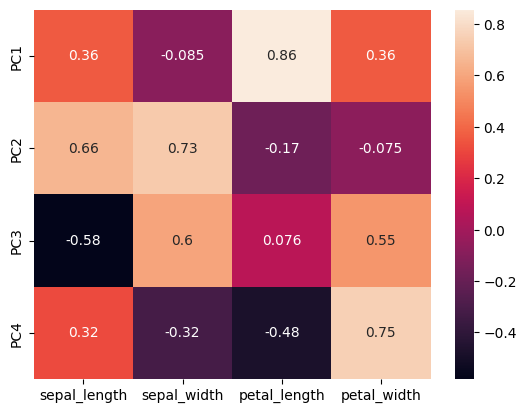

In [ ]:
# practiquemos con gráficos, nos ayudan a entender mejor la información
ax = sns.heatmap(componentes, annot=True)

In [ ]:
# Veamos la varianza explicada de cada componente
# para eso utilizamos .explained_variance_ratio_
print(lista_componentes)
print(modelo_pca.explained_variance_ratio_.round(2)*100)

['PC1', 'PC2', 'PC3', 'PC4']
[92.  5.  2.  1.]


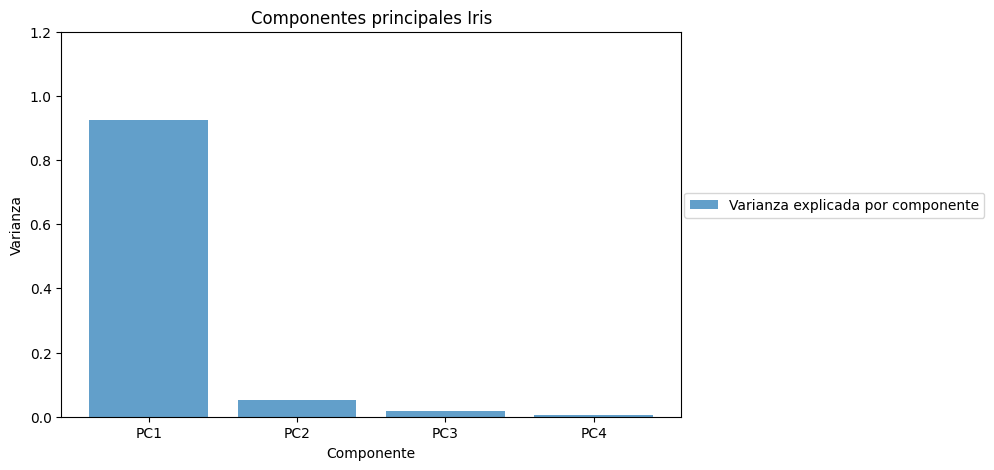

In [ ]:
# Practiquemos con gráficos, nos ayudan a entender mejor la información
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(lista_componentes, modelo_pca.explained_variance_ratio_, alpha=0.7, label='Varianza explicada por componente')


ax.set_title('Componentes principales Iris')
ax.set_xlabel('Componente')
ax.set_ylabel('Varianza')
ax.set_ylim(0, 1.2)
ax.legend(bbox_to_anchor = (1.5, 0.6))

In [ ]:
# cuando utilizamos .transform estamos calculando la función para cada dato y generando el resultado
# luego lo guardamos en un dataframe para poder utilizarlo más facilmente
proyecciones = pd.DataFrame(modelo_pca.transform(df_2), index=df_2.index,columns=lista_componentes)
proyecciones

,PC1,PC2,PC3,PC4
0,-2.684126,0.319397,-0.027915,0.002262
1,-2.714142,-0.177001,-0.210464,0.099027
2,-2.888991,-0.144949,0.017900,0.019968
3,-2.745343,-0.318299,0.031559,-0.075576
4,-2.728717,0.326755,0.090079,-0.061259
...,...,...,...,...
145,1.944110,0.187532,0.177825,0.426196
146,1.527167,-0.375317,-0.121898,0.254367
147,1.764346,0.078859,0.130482,0.137001
148,1.900942,0.116628,0.723252,0.044595


En este punto hicimos la transformación pero aún tenemos 4 variables, y como nuestro objetivo es simplificar el problema, debemos escoger con cuantas variables nos vamos a quedar. Para esto podemos usar el siguiente criterio:
##1. Varianza acumulada superior a un umbral



In [ ]:
proyecciones.drop(columns=['PC3', 'PC4'], inplace=True)

In [ ]:
proyecciones

,PC1,PC2
0,-2.684126,0.319397
1,-2.714142,-0.177001
2,-2.888991,-0.144949
3,-2.745343,-0.318299
4,-2.728717,0.326755
...,...,...
145,1.944110,0.187532
146,1.527167,-0.375317
147,1.764346,0.078859
148,1.900942,0.116628


Con este criterio podemos ver la gráfica que realizamos previamente, usualmente se considera un buen umbral el 80%, así que con la primera variable ya tendriamos suficiente, no obstante, veamos los histogramas en detalle

In [ ]:
# Agreguemos la columna de las especies para poderla utilizar más adelante
proyecciones['species'] = df['species'] # Esto solo funciona por que tienen el mismo index
proyecciones

,PC1,PC2,species
0,-2.684126,0.319397,setosa
1,-2.714142,-0.177001,setosa
2,-2.888991,-0.144949,setosa
3,-2.745343,-0.318299,setosa
4,-2.728717,0.326755,setosa
...,...,...,...
145,1.944110,0.187532,virginica
146,1.527167,-0.375317,virginica
147,1.764346,0.078859,virginica
148,1.900942,0.116628,virginica


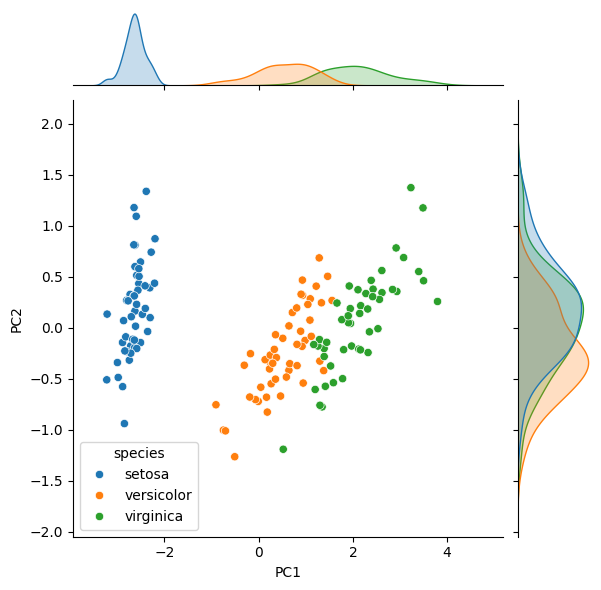

In [ ]:
# Practiquemos con un gráfico de seaborn, así podremos ver la distribución y la relación entre las componentes 1 y 2
g = sns.jointplot(x='PC1', y='PC2', data=proyecciones, hue="species", palette="tab10")
g.fig.set_figwidth(6)

#La función jointplot crea un gráfico en el que se muestra la distribución de los valores de dos variables en
#forma de histogramas, y también traza una gráfica de dispersión para mostrar la relación entre ambas variables.

PCA separa muy bien las especies. Tengan en cuenta que PCA no sabe de las clases. Lo único que busca es juntar varianza. Debido a que las clases tienen que ver con la varianza, reducir la dimensionalidad nos ayuda.

In [ ]:
proyecciones.species.value_counts(normalize=True)*100

,proportion
species,
setosa,33.333333
versicolor,33.333333
virginica,33.333333


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn import metrics

In [ ]:
proyecciones_features=proyecciones[["PC1", "PC2"]]
proyecciones_features

,PC1,PC2
0,-2.684126,0.319397
1,-2.714142,-0.177001
2,-2.888991,-0.144949
3,-2.745343,-0.318299
4,-2.728717,0.326755
...,...,...
145,1.944110,0.187532
146,1.527167,-0.375317
147,1.764346,0.078859
148,1.900942,0.116628


In [ ]:
proyecciones_target=proyecciones[["species"]]
proyecciones_target

,species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa
...,...
145,virginica
146,virginica
147,virginica
148,virginica


In [ ]:
# Separamos en entrenamiento/test en razon 80/20 %
X_train, X_test, y_train, y_test = train_test_split(proyecciones_features,proyecciones_target,test_size=0.2, random_state=2,stratify=proyecciones_target)
# Creamos un KNN
modelo = KNeighborsClassifier(n_neighbors=4)
modelo.fit(X_train, y_train)
# Obtenemos las predicciones del modelo con X_test


/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=4)

In [ ]:
preds_train = modelo.predict(X_train)
preds_test = modelo.predict(X_test)

In [ ]:
y_test

,species
45,setosa
120,virginica
126,virginica
8,setosa
58,versicolor
122,virginica
136,virginica
113,virginica
18,setosa
22,setosa


In [ ]:
preds_test

array(['setosa', 'virginica', 'virginica', 'setosa', 'versicolor',
       'virginica', 'virginica', 'virginica', 'setosa', 'setosa',
       'versicolor', 'versicolor', 'versicolor', 'virginica', 'setosa',
       'virginica', 'versicolor', 'setosa', 'virginica', 'setosa',
       'versicolor', 'virginica', 'setosa', 'versicolor', 'versicolor',
       'virginica', 'virginica', 'setosa', 'versicolor', 'setosa'],
      dtype=object)

In [ ]:
print(metrics.classification_report(y_train, preds_train))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        40
  versicolor       0.95      0.97      0.96        40
   virginica       0.97      0.95      0.96        40

    accuracy                           0.97       120
   macro avg       0.98      0.97      0.97       120
weighted avg       0.98      0.97      0.97       120



In [ ]:
print(metrics.classification_report(y_test, preds_test))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

